In [4]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import re
from textblob import TextBlob
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import umap
import plotly.express as px
import plotly.graph_objects as go
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

In [37]:
#выгружаем статьи
file_path = "/Users/MAC/Desktop/Компьютерная лингвистика/articles100.txt"

def split_articles_by_title(file_path):
    with open(file_path, encoding="utf-8") as file:
        content = file.read()
    # Разделяем содержимое по вхождениям "Title:" с сохранением этого слова в начале каждого блока
    articles = content.split("\nTitle:")
    
    # Очищаем каждую статью от лишних пробелов и символов
    articles = [article.replace('\n', ' ').strip() for article in articles]
    
    return articles

articles = split_articles_by_title(file_path)

#Выводим первую статью
print(articles[0])

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Title: Combining Machine Learning and Computational Chemistry for Predictive Insights Into Chemical Systems Text:  Machine learning models are poised to make a transformative impact on chemical sciences by dramatically accelerating computational algorithms and amplifying insights available from computational chemistry methods. However, achieving this requires a confluence and coaction of expertise in computer science and physical sciences. This Review is written for new and experienced researchers working at the intersection of both fields. We first provide concise tutorials of computational chemistry and machine learning methods, showing how insights involving both can be achieved. We follow with a critical review of noteworthy applications that demonstrate how computational chemistry and machine learning can be used together to prov

In [38]:
#предопределенный список названий моделей и их сокращений
model_names = {
    "Random Forest": "RF",
    "Support Vector Machine": "SVM",
    "Neural Network": "NN",
    "Decision Tree": "DT",
    "K-Nearest Neighbors": "KNN",
    "Gradient Boosting": "GB",
    "XGBoost": "XGB",
    "LightGBM": "LGBM",
    "CatBoost": "CB",
    "Logistic Regression": "LR"
}

#объединем текст в строку для анализа
text_data = ' '.join(articles)

#подсчет частоты встречаемости
frequency = {model: text_data.count(model) + text_data.count(abbr) for model, abbr in model_names.items()}

#создаем DataFrame для удобного отображения
model_frequency = pd.DataFrame({
    'Model': frequency.keys(),
    'Frequency': frequency.values()
})

print("Частота встречаемости моделей:")
sorted_frequency = model_frequency[model_frequency['Frequency'] > 0].sort_values(by='Frequency', ascending=False)
print(sorted_frequency)




#функция для анализа тональности
def analyze_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity  #функция возвращает полярность текста, которая варьируется от -1 (отрицательная тональность) до 1 (положительная тональность)

#вывод контекста и эмоциональной окраски для каждой модели
context_window = 150  #количество символов до и после модели
for model in model_names.keys():
    if frequency[model] > 0:
        #находим все вхождения модели
        matches = [m.start() for m in re.finditer(model, text_data)]
        print(f"\nКонтекст для модели '{model}':")
        for match in matches:
            start = max(0, match - context_window)
            end = min(len(text_data), match + len(model) + context_window)
            context = text_data[start:end]
            sentiment_score = analyze_sentiment(context)
            print(f"Контекст: {context.strip()}")
            print(f"Эмоциональная окраска (полярность): {sentiment_score:.2f}")
            print("-" * 80)  

        #также выводим контекст для сокращений
        abbr = model_names[model]
        matches_abbr = [m.start() for m in re.finditer(abbr, text_data)]
        for match in matches_abbr:
            start = max(0, match - context_window)
            end = min(len(text_data), match + len(abbr) + context_window)
            context = text_data[start:end]
            sentiment_score = analyze_sentiment(context)
            print(f"Контекст: {context.strip()}")
            print(f"Эмоциональная окраска (полярность): {sentiment_score:.2f}")
            print("-" * 80)  


Частота встречаемости моделей:
                    Model  Frequency
2          Neural Network       2910
1  Support Vector Machine        690
3           Decision Tree        315
0           Random Forest        240
4     K-Nearest Neighbors        155
5       Gradient Boosting        135
8                CatBoost        135
6                 XGBoost         90
9     Logistic Regression         70

Контекст для модели 'Random Forest':
Контекст: rdinary Least Squares Regression(OLS), Naive Bayesian classification(NB), Logistic Regression(LR), Support Vector Machine(SVM), Ensemble methods(EM), Random Forests linear regression(RF), Linear Discriminant Analysis (LD), k-nearest neighbor algorithm(k-NN), Multi-layer perceptron(MLP), Convolutional neural netw
Эмоциональная окраска (полярность): -0.37
--------------------------------------------------------------------------------
Контекст: the range of activity values, the authors argue that regression is also not favorable for in silico targ

Контекст для модели 'Random Forest':

- Контекст: nd gradient boosting (GB) models can be successfully applied to predict malaria using patient information (Lee et al., 2021). The graph-based MLP and RF models effectively diagnosed influenza and hepatitis, respectively (Alqaissi et al., 2023). In addition, machine learning algorithms for taxonomic cl
Эмоциональная окраска (полярность): 0.45

- модели (GB) могут быть успешно применены для прогнозирования малярии с использованием информации о пациентах (Lee et al., 2021). Графические модели NLP и RF эффективно диагностировали грипп и гепатит соответственно (Al kaissi et al., 2023). Кроме того, алгоритмы машинного обучения для таксономической классификации

#### выделение общих тем в статьях

In [40]:
#инициализация лемматизатора
nltk.download('wordnet')  #загрузка словаря WordNet
lemmatizer = WordNetLemmatizer()


#фильтруем по части речи и возвращаем только начальную форму.
def normalize_english(text):
    tokens = re.findall(r'\b\w+\b', text)  #находим все слова
    words = []
    for t in tokens:
        #лемматизация слова
        word = lemmatizer.lemmatize(t.lower())  
        words.append(word)
    return words

[nltk_data] Downloading package wordnet to /Users/MAC/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


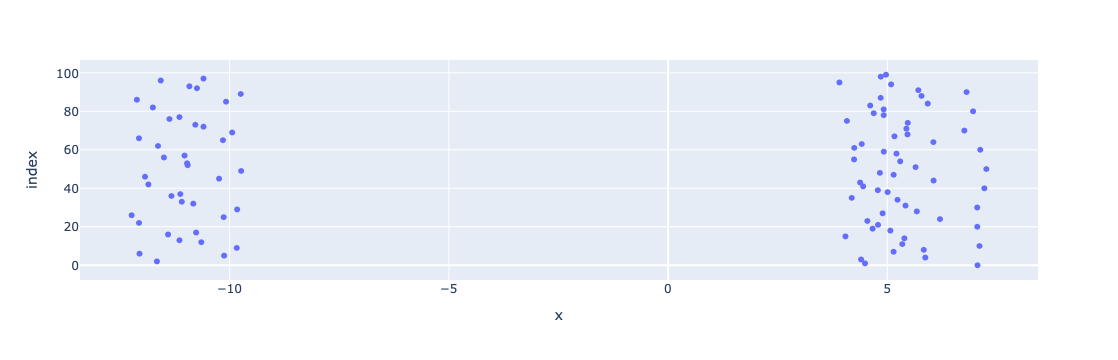

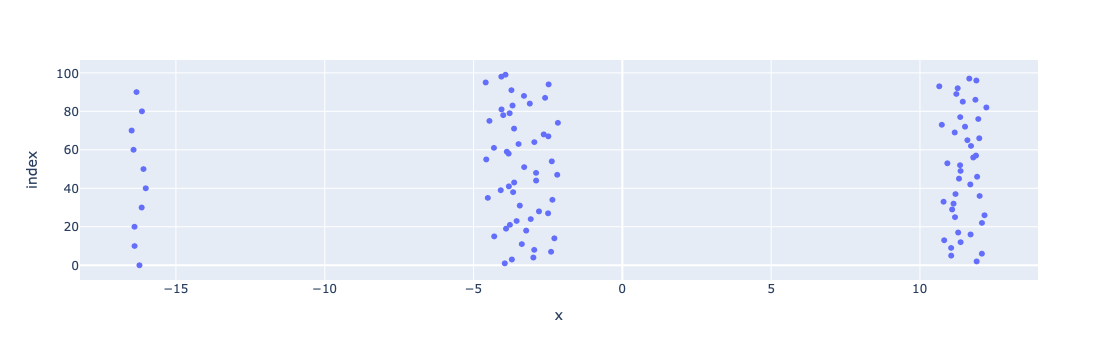

In [41]:
#приведем слова в текстах к начальным формам.
articles_proc = map(lambda x: ' '.join(normalize_english(x)), articles)
X_w = TfidfVectorizer().fit_transform(articles_proc) #cоздается экземпляр TfidfVectorizer, который преобразует нормализованные статьи в матрицу TF-IDF
#на выходе матрица, где строки представляют статьи, а столбцы — слова. Значения в матрице представляют собой вес слов в статьях.    

#применяем SVD и UMAP
svd = TruncatedSVD(n_components=30)#используется для уменьшения размерности матрицы
X2_w = svd.fit_transform(X_w)

umap_w = umap.UMAP()#используется для уменьшения размерности данных
X_w_u = umap_w.fit_transform(X_w)


#визуализация
fig = px.scatter(X_w_u[:, 0], X_w_u[:, 1],
                 hover_name=[n[:100] for n in articles])
fig.show()


#применяем UMAP к SVD
umap_w = umap.UMAP()
X2_w_u = umap_w.fit_transform(X2_w)


fig = px.scatter(X2_w_u[:, 0], X2_w_u[:, 1],
                 hover_name=[n[:100] for n in articles])
fig.show()

Построим разное количество компонент и оценим их правдоподобие по Акайке. (чем ниже значение тем лучше модель)

In [44]:
gm1 = GaussianMixture(n_components=10)
gm1_res = gm1.fit(X2_w_u)
gm1_res.aic(X2_w_u)

483.4029091689615

In [45]:
gm2 = GaussianMixture(n_components=8)
gm2_res = gm1.fit(X2_w_u)
gm2_res.aic(X2_w_u)

479.5062667338553

In [48]:
gm2 = GaussianMixture(n_components=5)
gm2_res = gm1.fit(X2_w_u)
gm2_res.aic(X2_w_u)

471.7885443735699

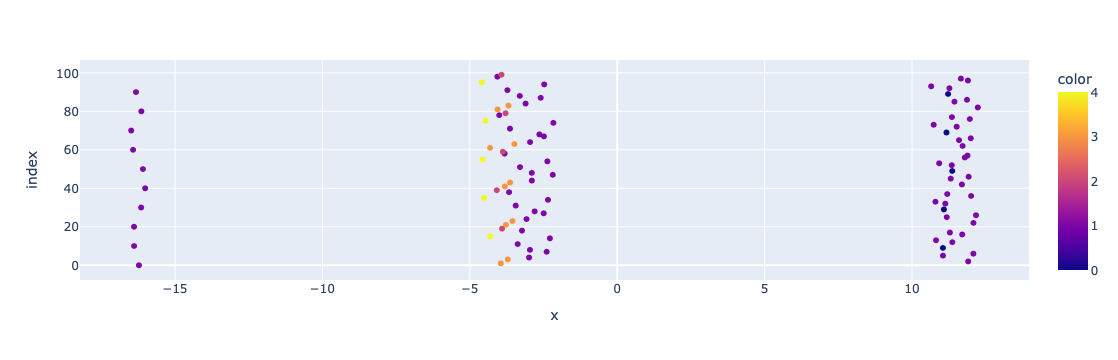

In [56]:
#Кластеризация
km = KMeans(n_clusters=5)
y_hat = km.fit_predict(X2_w)


fig = px.scatter(X2_w_u[:, 0], X2_w_u[:, 1],
                 hover_name=[n[:100] for n in articles],
                 color=y_hat)
fig.show()

In [57]:
#вывод текстов из определенного кластера
coi = 1
cnt = 0
for n, c in zip(articles, y_hat):
    if c == coi:
        print(n[:300], '\n=====\n')
        cnt += 1
        if cnt == 5:
            break

Title: Combining Machine Learning and Computational Chemistry for Predictive Insights Into Chemical Systems Text:  Machine learning models are poised to make a transformative impact on chemical sciences by dramatically accelerating computational algorithms and amplifying insights available from comp 
=====

Machine Learning for Toxicity Prediction Using Chemical Structures: Pillars for Success in the Real World Text:  Machine learning (ML) is increasingly valuable for predicting molecular properties and toxicity in drug discovery. However, toxicity-related end points have always been challenging to eva 
=====

Prospects and Challenges of Using Machine Learning for Academic Forecasting Text: The study examines the prospects and challenges of machine learning (ML) applications in academic forecasting. Predicting academic activities through machine learning algorithms presents an enhanced means to accurately 
=====

Machine Learning Aided Design and Optimization of Thermal Metamaterials T

- Название: Объединение машинного обучения и вычислительной химии для прогнозного анализа химических систем Текст: Модели машинного обучения способны оказать преобразующее влияние на химические науки, значительно ускоряя вычислительные алгоритмы и расширяя возможности, доступные в comp 


- Машинное обучение для прогнозирования токсичности с использованием химических структур: основа успеха в реальном мире Текст: Машинное обучение (ML) становится все более ценным для прогнозирования молекулярных свойств и токсичности при разработке лекарств. Однако конечные точки, связанные с токсичностью, всегда были сложной задачей для eva 


- Перспективы и проблемы использования машинного обучения для академического прогнозирования Текст: В исследовании рассматриваются перспективы и проблемы применения машинного обучения (ML) в академическом прогнозировании. Прогнозирование академической деятельности с помощью алгоритмов машинного обучения представляет собой усовершенствованное средство точного 


- Машинное обучение, автоматизированное проектирование и оптимизация тепловых метаматериалов Текст: Искусственный интеллект (ИИ) продвинул исследования материалов, которые ранее были трудноразрешимыми, например, машинное обучение (ML) смогло предсказать некоторые беспрецедентные тепловые свойства. В этом обзоре мы впервые 


- Руководство по использованию машинного обучения для извлечения знаний из данных в биологической психиатрии Текст: Применение машинного обучения в биомедицинских науках быстро развивается. Этому росту способствовали разнообразные формы межведомственного и междисциплинарного сотрудничества, доступность для общественности